# Notebook tips and tricks 
Hey reader! :) This notebook was compiled on the basis of things I frequently saw when checking notebooks, hope this might be useful for you when doing the assignments! Thinking in matrices and matrix manipulations is a large step forward in your understanding of machine learning in general. Although some of these guidelines may seem a bit harsh, they will lead to a better, more comprehensive notebook (and will potentially help you on the exam!). 

Hope this helps, good luck and have fun with the assignments!

## General things to be covered
- [Good code practice](#Good-code-practice)
- [Justifying your answers](#Justifying-your-answers)
- [What to do when you get stuck?](#What-to-do-when-you-get-stuck?)
- [Handing in notebooks](#Handing-in-notebooks)
- [Some useful resources](Useful-resources)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.covariance import shrunk_covariance

### Good code practice
Name your graphs (add titles), and give them informative x and y-axes (add labels). Make sure to describe what can be seen in the figure (add legends). What data is visualized? If there are multiple graphs or coloured dots used, what do they signify? A figure and its description must be self-explanatory without other (textual) context. If there are different colours used within a plot, use a legend to indicate which colour indicates what feature.

This is also important for the exam, so do take note of that. Below is a good example from one of the submissions I received for assignment 2.

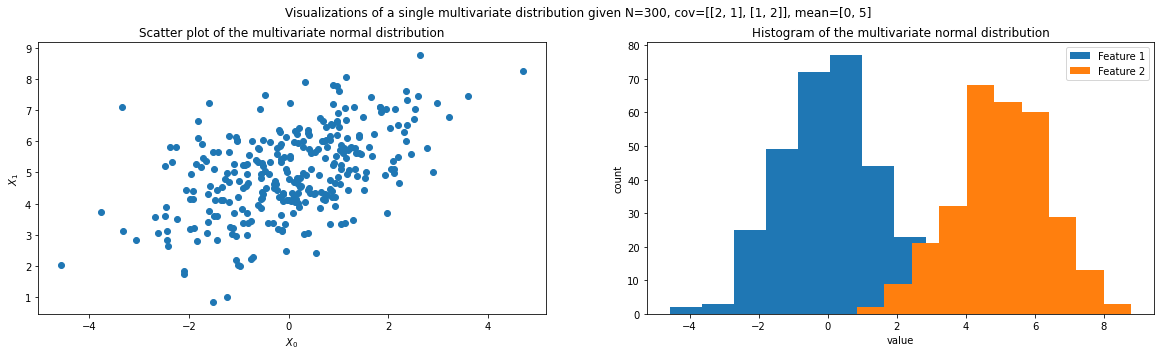

In [2]:
def generate_data(N_samples=300, cov=[[2, 1], [1, 2]], mean=[0, 5]):
    X = np.random.multivariate_normal(mean, cov, N_samples)
    return X


np.random.seed(42)  # ensures replicable results
X = generate_data()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
fig.suptitle("Visualizations of a single multivariate distribution given N=300, cov=[[2, 1], [1, 2]], mean=[0, 5]")

# Answer here
ax[0].scatter(X[:,0], X[:,1])
ax[0].set_title("Scatter plot of the multivariate normal distribution")
ax[0].set_xlabel("$X_0$")
ax[0].set_ylabel("$X_1$")

ax[1].set_title("Histogram of the multivariate normal distribution")
ax[1].hist(X[:,0], label="Feature 1")
ax[1].hist(X[:,1], label="Feature 2")
ax[1].set_xlabel("value")
ax[1].set_ylabel("count")
ax[1].legend()

### Justifying your answers
Justify your answers! This means that you should give a small explanation why you chose a particular classifier, or why you chose to do a certain transformation. When stuck, give a comment that you tried X, or if you weren't sure about the correct answer, write it down anyway. This way, I can see whether you understood the question or whether you wrote down some code/answer and didn't fully understand why you did it.

Additionally, feel free to make mistakes. This will allow us as teachers to get feedback on which parts need more attention, which we subsequently might take up in the next flipped-classroom session.

**Example question**:  Which LDA assumption(s) are violated by the provided dataset?

**Example answer**:  _The dataset violates the Gaussianity distribution of the features_ (**answer**), as seen by the exponential behavior of feature x2 (**justification**).


### What to do when you get stuck?
**TL;DR: When in doubt, use the Brightspace forum or Discord.** We acknowledge that the lack of any (physical) practical sessions can harm your progress with the assignments. Please, note that the Brightspace discussion forum and Discord are there to post and answer questions. Please use this, so that everyone has access to questions and answers. We kindly ask you to plan ahead, so that the number of questions does not explode before the (soft) deadline.

Don't be afraid to ask questions you think are silly - there are of course no silly questions! We'll try to respond as soon as possible, but do note that it could take a bit of time, as we're currently only with the 3 of us. Also try to answer the questions of other groups, you're definitely not the only one that got stuck at a certain exercise.  

### When do I use element-wise multiplication, and when do I use the matrix multiplication?** 

We will use the following formula to illustrate this: $C = A \cdot B$, where

- C is a matrix of $m \cdot n$ elements
- A is a matrix of $m \cdot n$ elements
- B is a matrix of $m \cdot n$ elements

Imagine you have a matrix A, containing 20 $\cdot$ 10 elements. You would like to multiply it with a matrix B, also containing 20 $\cdot$ 10 elements. In this case, you would use element-wise multiplication (the dot product), as you see that the shapes of A and B are the same.

#### An example in Python would look as follows

In [3]:
# In Python/numpy * indicates element-wise multiplication

A = np.array([[1, 2], [3, 4]])
B = np.array([[1, 1], [2, 2]])
C = A * B
print(C)

[[1 2]
 [6 8]]


In order to use matrix multiplication, you need to take into account the following formula: $C = A \cdot B$, where

- C is a matrix of $m \cdot n$ elements
- A is a matrix of $m \cdot k$ elements
- B is a matrix of $k \cdot n$ elements

Imagine you have a matrix A, containing 4 $\cdot$ 2 elements. You would like to multiply it with a vector B, also containing 10 $\cdot$ 2 elements. In this case, you would use matrix multiplication, as you see that the shapes of X and Y are not the same, but that they do have a common factor, which is $k$ in this case.

#### An example in Python would look as follows

In [4]:
# In Python/numpy np.dot() indicates matrix multiplication

A = np.array([[1, 2], [3, 4]])
B = np.array([[1, 1], [2, 2]])
C = np.dot(A, B)
print(C)

[[ 5  5]
 [11 11]]


Note that $A*B$ (element wise multiplication) and $A.B$ (matrix multiplication) differ in their output! In general, think clearly about when to use the one over the other. Specifically, the difference is that elemenwise multiplication only computes elementwise products, while the matrix multiplication computes an actual matrix product that contains inner/outer products that also perform a sum after elementwise multiplication. Note the difference below:

In [5]:
v = np.array([1, 2])
w = np.array([3, 4])

print("output elementwise:", v * w)

print("output dot product:", np.dot(v, w))

output elementwise: [3 8]
output dot product: 11


Also, please do not just check dimensions and see if things fit. Think about what the input is, and what the output should be **conceptually**. Then think about whether you need elementwise products or matrix products. 

Be careful with elementwise products, as they may also do "clever" things in the background like *broadcasting*. Look at the folowing, and try to understand what is happening:

In [6]:
v = np.array([1, 2])
w = np.array([[1], [2]])
A = np.array([[1, 2], [3, 4]])

print("\nv\n", v)
print("\nw\n", w)
print("\nA\n", A)

print("\nv*A\n", v*A) # broadcasting happened, can you explain what it did?

print("\nw*A\n", w*A) # broadcasting happened, can you explain what it did?

# Can you explain the difference between v*A and w*A, given the difference between v and w?


v
 [1 2]

w
 [[1]
 [2]]

A
 [[1 2]
 [3 4]]

v*A
 [[1 4]
 [3 8]]

w*A
 [[1 2]
 [6 8]]


### My dimensions didn't match with these operation, how should I proceed with this exercise?

Check out the shapes of the vector/matrices you'd like to multiply. Most of the times, the hint in fixing it lies here. If you want to loop over items in `X`, you can build a for loop. Stop doing `for x in X`, as this loops (implicitly) over the first dimension. Instead, do something like `for i in range(q); x = X[i, :]`, which does the same, but now explicitly loops over the first dimension. Now, if you need the second dimension, do not do `for x in X.T`, but instead do `x = X[:, i]`, as this would grab the second dimension explicitly (and without changing the shape of `x`).

For a multidimensional matrix (numpy array), try not to index with `x = X[i]`, as this again (implicitly) index in the first dimension. Use "explicit indexing", like `x = X[i, :]` or `x = X[:, i]`. 

In `X[:, i]`, we basically say 'take everything from the first dimension, and only the ith one of the second'. In a similar vein, `X[4:7, i]` takes items 4 to 7 in the first dimension and only `i` in the second. The `:` operator is a slicing operator. Can you explain what `X[:4, :]` does? What does `X[:-1, :]` do? What does `X[::2, :]` do?

### Axis parameter
Also note that numpy functions have an *axis* parameter. Look at the differences below, make sure to understand them.

In [7]:
A = np.array([[1, 2], [3, 4]])

print(np.mean(A))
print(np.mean(A, axis=0))
print(np.mean(A, axis=1))

2.5
[2. 3.]
[1.5 3.5]


### Handing in notebooks
It would be helpful if you could hand in the notebooks with all the cells executed. This saves a bit of time when checking, and where I don't have to copy-paste a dataset from one folder to another, in case you might have accidentally put the data somewhere else. For this, before submitting a notebook, click the `Kernel->Restart & Run All` option.

### Useful resources
You might want to check out assignment 1a and 1b again, these contain a lot of useful tips! Check out [Khan Academy](https://www.khanacademy.org) online if you need to refresh your knowledge, or ask your fellow peers for help. I would like to emphasise again that the workload should be balanced, especially during these times. Please keep an eye on each other and help each other where needed. Keep an active attitude toward your group members and feel responsible for each other and the group work. 
